# EDA – Dimensión Clima (df_clima)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

df_clima = pd.read_csv("../../data/Experimental/clima_provincia_mes.csv",
                      encoding="utf-8-sig",
                      dtype=str,
                      keep_default_na=False,
                      na_filter=False
                      )

In [27]:
# 2) Convertir columnas numéricas (ajusta si tienes más)
for col in ["temp_media_mes", "precip_total_mes"]:
    if col in df_clima.columns:
        df_clima[col] = pd.to_numeric(df_clima[col], errors="coerce")

# 3) Crear columna fecha = mes + "-01"
#    (asumiendo df["mes"] está en formato "YYYY-MM")
df_clima["fecha"] = pd.to_datetime(df_clima["mes"].astype(str) + "-01", errors="coerce")

In [28]:
df_clima.head(10)

,cpro,provincia,mes,temp_media_mes,precip_total_mes,id_clima,fecha
0,01,araba/álava,2023-01,4.135484,108.7,1,2023-01-01
1,01,araba/álava,2023-02,4.035714,45.9,2,2023-02-01
2,01,araba/álava,2023-03,9.861290,34.2,3,2023-03-01
3,01,araba/álava,2023-04,11.373333,63.1,4,2023-04-01
4,01,araba/álava,2023-05,13.029032,84.5,5,2023-05-01
5,01,araba/álava,2023-06,17.956667,137.8,6,2023-06-01
6,01,araba/álava,2023-07,19.358065,27.1,7,2023-07-01
7,01,araba/álava,2023-08,20.458065,23.4,8,2023-08-01
8,01,araba/álava,2023-09,19.033333,66.4,9,2023-09-01
9,01,araba/álava,2023-10,16.467742,74.3,10,2023-10-01


In [29]:
# Información general
df_clima.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_clima.columns,
    "Data Type": df_clima.dtypes.values,
    "NULLs allowed": ["Y" if df_clima[c].isna().any() else "N" for c in df_clima.columns],
    "NULL %": [round(df_clima[c].isna().mean()*100, 2) for c in df_clima.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   cpro              1976 non-null   object        
 1   provincia         1976 non-null   object        
 2   mes               1976 non-null   object        
 3   temp_media_mes    1976 non-null   float64       
 4   precip_total_mes  1976 non-null   float64       
 5   id_clima          1976 non-null   object        
 6   fecha             1976 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 108.2+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,cpro,object,N,0.0
1,provincia,object,N,0.0
2,mes,object,N,0.0
3,temp_media_mes,float64,N,0.0
4,precip_total_mes,float64,N,0.0
5,id_clima,object,N,0.0
6,fecha,datetime64[ns],N,0.0


In [30]:
df_clima["cpro"].str.len().max()

np.int64(2)

In [31]:
df_clima["provincia"].str.len().max()

np.int64(22)

In [32]:
df_clima["mes"].str.len().max()

np.int64(7)

In [33]:
df_clima["id_clima"].str.len().max()

np.int64(4)

In [34]:
df_clima["temp_media_mes"].min()
df_clima["temp_media_mes"].max()

np.float64(31.961290322580645)

In [35]:
df_clima["precip_total_mes"].min()
df_clima["precip_total_mes"].max()

np.float64(629.1)

In [36]:
# ==========================================
# 3. RESUMEN (equivalente a group_by + summarise(across(mean)))
# ==========================================
# En tu dataset ya suele venir agregado por provincia-mes,
# pero replicamos el resumen por si hay duplicados.
num_cols = df_clima.select_dtypes(include=[np.number]).columns.tolist()

clima_resumen = (
    df_clima.groupby(["provincia", "fecha"], as_index=False)[num_cols]
      .mean(numeric_only=True)
)

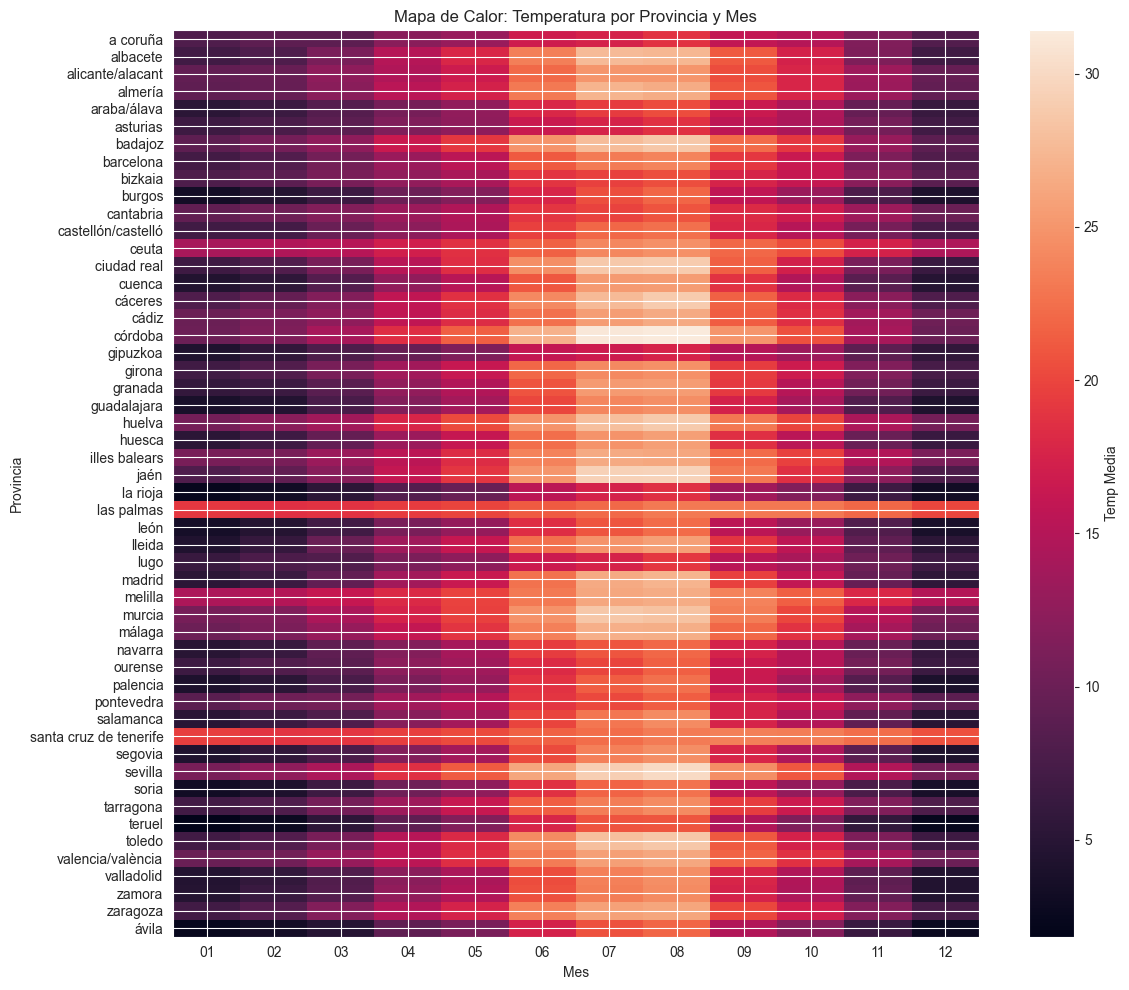

In [37]:
# ==========================================
# 4. MAPA DE CALOR: Temperatura por Provincia y Mes
# ==========================================
# Pivot: filas=provincia, columnas=mes (01..12 o fecha), valores=temp_media_mes
temp_pivot = clima_resumen.pivot_table(
    index="provincia",
    columns=clima_resumen["fecha"].dt.strftime("%m"),
    values="temp_media_mes",
    aggfunc="mean"
)

plt.figure(figsize=(12, 10))
plt.imshow(temp_pivot.values, aspect="auto")
plt.colorbar(label="Temp Media")
plt.yticks(range(len(temp_pivot.index)), temp_pivot.index)
plt.xticks(range(len(temp_pivot.columns)), temp_pivot.columns)
plt.title("Mapa de Calor: Temperatura por Provincia y Mes")
plt.xlabel("Mes")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

El uso de mapas de calor facilita la identificación visual de temporadas óptimas, permitiendo integrar recomendaciones automáticas dentro de una aplicación digital.

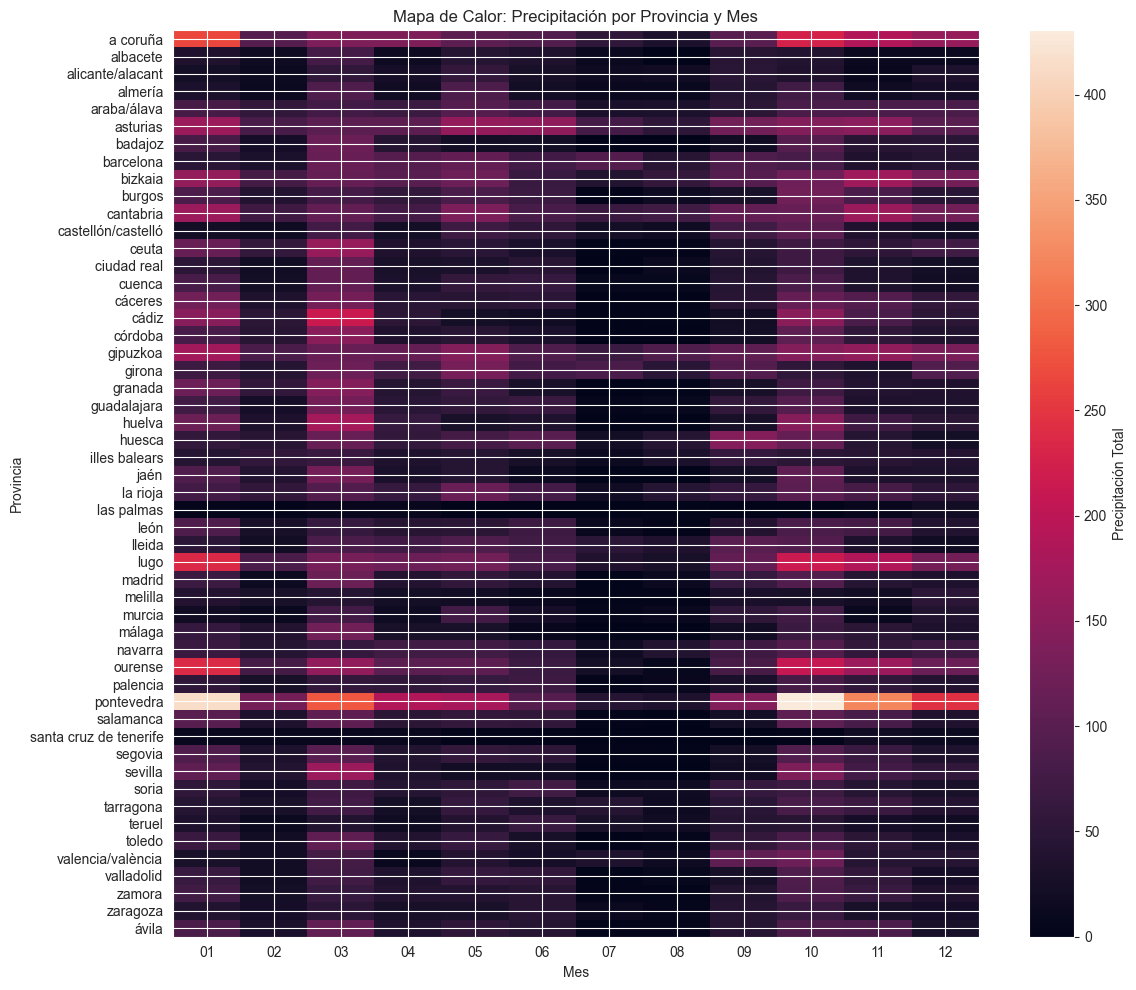

In [38]:
# ==========================================
# 5. MAPA DE CALOR: Precipitación por Provincia y Mes
# ==========================================
precip_pivot = clima_resumen.pivot_table(
    index="provincia",
    columns=clima_resumen["fecha"].dt.strftime("%m"),
    values="precip_total_mes",
    aggfunc="mean"
)

plt.figure(figsize=(12, 10))
plt.imshow(precip_pivot.values, aspect="auto")
plt.colorbar(label="Precipitación Total")
plt.yticks(range(len(precip_pivot.index)), precip_pivot.index)
plt.xticks(range(len(precip_pivot.columns)), precip_pivot.columns)
plt.title("Mapa de Calor: Precipitación por Provincia y Mes")
plt.xlabel("Mes")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

En el caso de la precipitación se puede ver una disminución notable de en los meses de junio y julio, lo cual permitiría analizar actividades al aire libre para la mayoría de cuidades

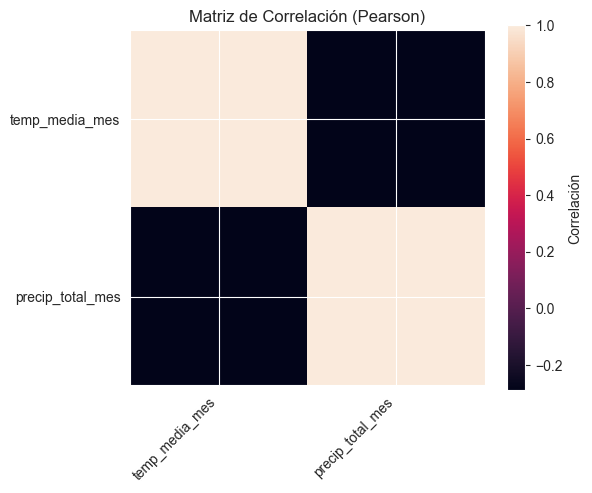

In [39]:
# ==========================================
# 7. MATRIZ DE CORRELACIÓN (equivalente a corrplot)
# ==========================================
# Selección numérica
num_cols = df_clima.select_dtypes(include=[np.number]).columns.tolist()

if len(num_cols) > 1:
    corr_matrix = df_clima[num_cols].corr(method="pearson", min_periods=1)

    plt.figure(figsize=(6, 5))
    plt.imshow(corr_matrix.values, aspect="equal")
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar(label="Correlación")
    plt.title("Matriz de Correlación (Pearson)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes columnas numéricas para correlación.")

La matriz de correlación permite analizar la relación entre la precipitación y la temperatura, sin embargo, tiene un factor de -0,2


Boxplot de temperatura media por provincia

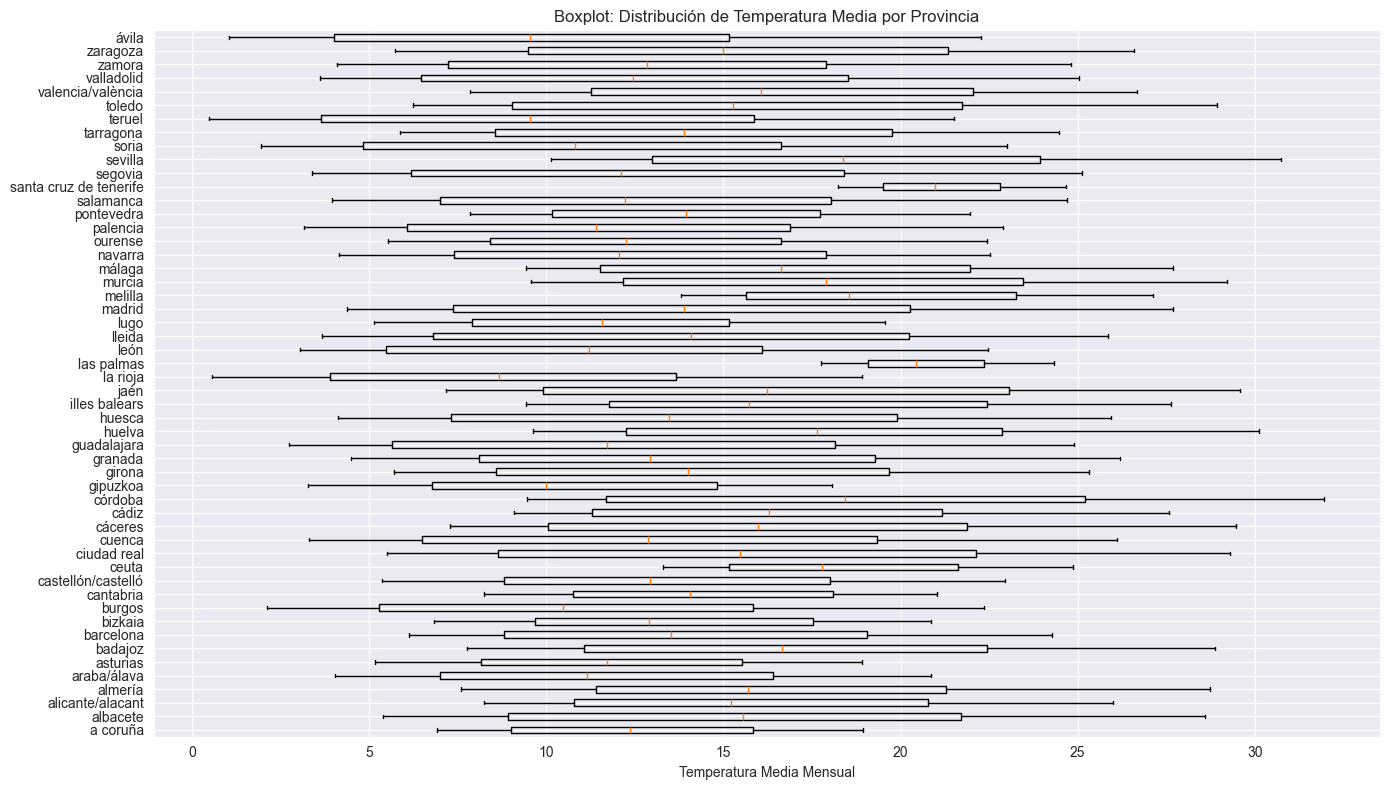

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegurar que la columna es numérica
df_clima["temp_media_mes"] = pd.to_numeric(df_clima["temp_media_mes"], errors="coerce")

# Eliminar nulos
df_temp = df_clima.dropna(subset=["temp_media_mes"])

# Agrupar valores por provincia
data = [
    df_temp[df_temp["provincia"] == prov]["temp_media_mes"].values
    for prov in sorted(df_temp["provincia"].unique())
]

plt.figure(figsize=(14, 8))
plt.boxplot(data, vert=False)
plt.yticks(range(1, len(sorted(df_temp["provincia"].unique())) + 1),
           sorted(df_temp["provincia"].unique()))
plt.xlabel("Temperatura Media Mensual")
plt.title("Boxplot: Distribución de Temperatura Media por Provincia")
plt.tight_layout()
plt.show()

Boxplot de precipitación por provincia

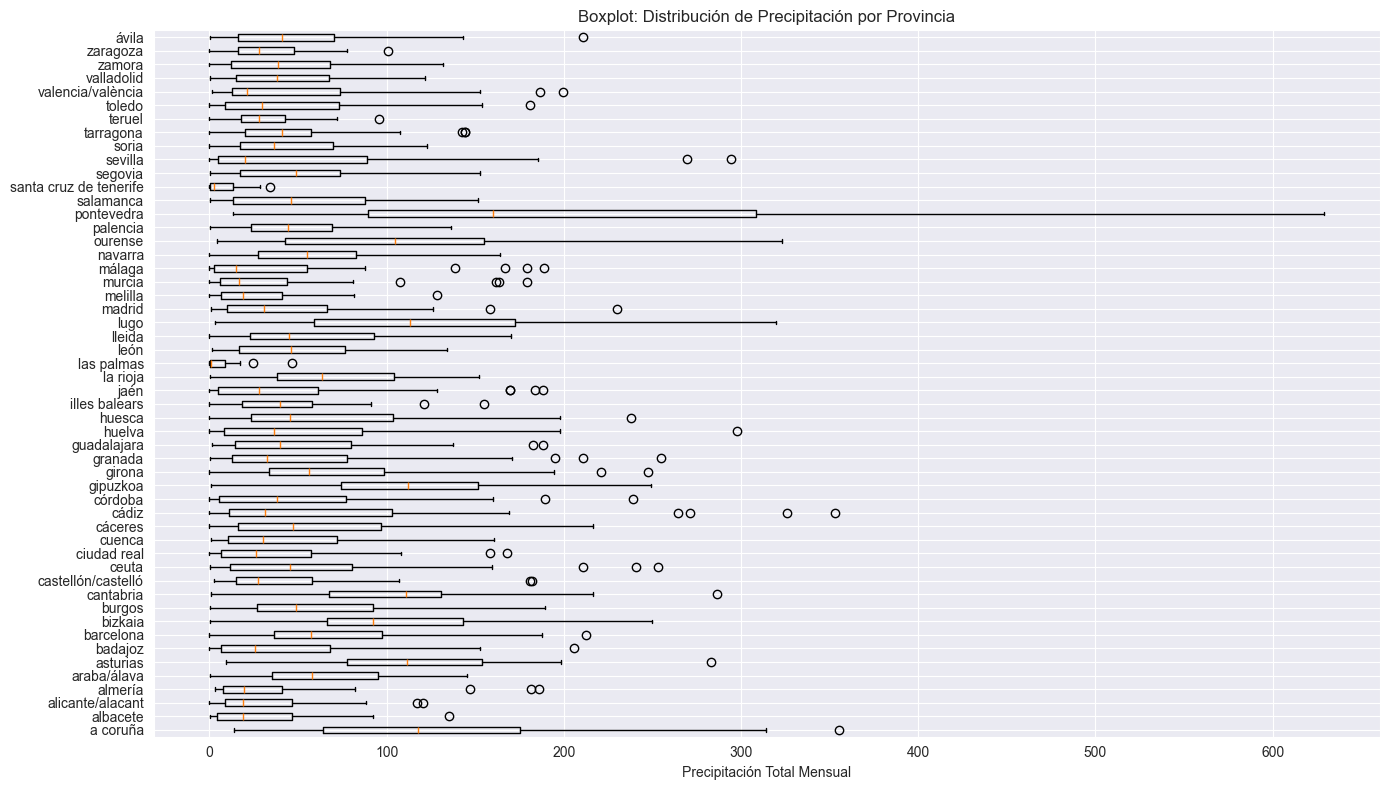

In [41]:
df_clima["precip_total_mes"] = pd.to_numeric(df_clima["precip_total_mes"], errors="coerce")
df_precip = df_clima.dropna(subset=["precip_total_mes"])

data = [
    df_precip[df_precip["provincia"] == prov]["precip_total_mes"].values
    for prov in sorted(df_precip["provincia"].unique())
]

plt.figure(figsize=(14, 8))
plt.boxplot(data, vert=False)
plt.yticks(range(1, len(sorted(df_precip["provincia"].unique())) + 1),
           sorted(df_precip["provincia"].unique()))
plt.xlabel("Precipitación Total Mensual")
plt.title("Boxplot: Distribución de Precipitación por Provincia")
plt.tight_layout()
plt.show()

Boxplot de temperatura por mes (muy útil para estacionalidad)

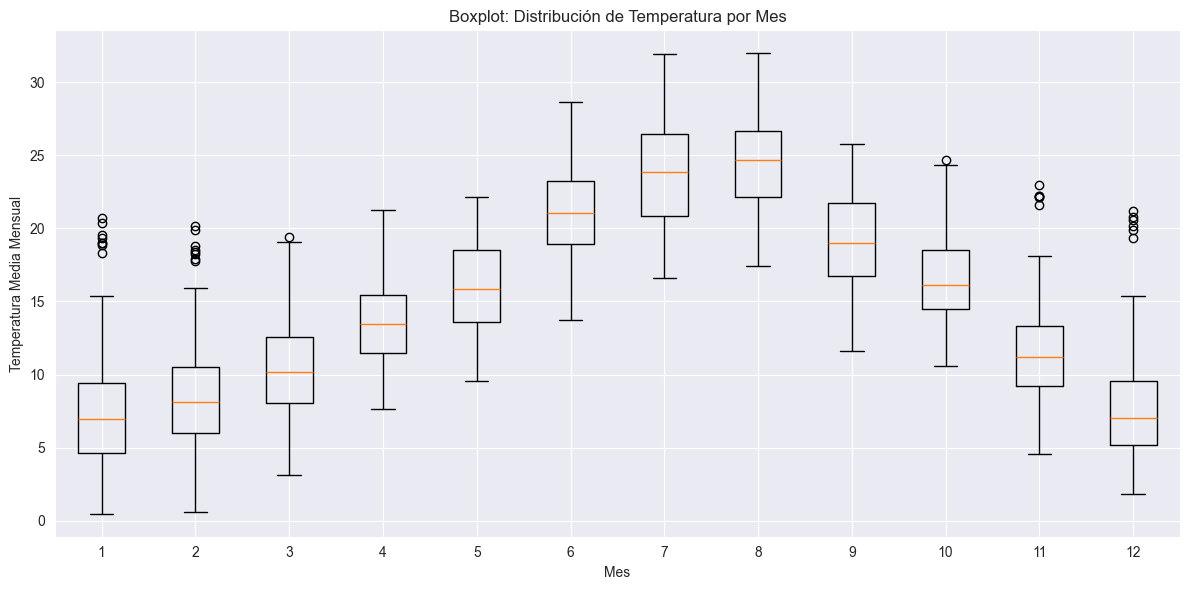

In [43]:
df_clima["fecha"] = pd.to_datetime(df_clima["mes"] + "-01", errors="coerce")
df_clima["mes_num"] = df_clima["fecha"].dt.month

data = [
    df_clima[df_clima["mes_num"] == m]["temp_media_mes"].values
    for m in range(1, 13)
]

plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xticks(range(1, 13), range(1, 13))
plt.xlabel("Mes")
plt.ylabel("Temperatura Media Mensual")
plt.title("Boxplot: Distribución de Temperatura por Mes")
plt.tight_layout()
plt.show()